In [1]:
!pip install nolds
!pip install hmmlearn
!pip install yfinance
!pip install statsmodels
!pip install hurst ruptures

In [2]:
import yfinance as yf
import datetime
from numpy import *
from pylab import plot, show

import pandas as pd
import numpy as np

import numpy as np
from pathlib import Path
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
#from google.colab import drive

In [3]:
#Umcomment this method when running from google colab
#def load_data_from_drive(start_date, end_date):
  #drive.mount('/content/drive', force_remount=True)
  #base_path = Path("/content/drive/My Drive/WQU/Capstone/data/parquet_out")
  #dfs = []
  #for d in sorted(base_path.iterdir()):
      #if d.is_dir() and start_date <= d.name <= end_date:
          #dfs.append(pd.read_parquet(d))

  #return pd.concat(dfs, ignore_index=True)


def load_data(start_date: str,
              end_date  : str,
              base_path : Path = Path("./data/NIFTYDATA"),
              symbol    : str  = "NIFTY 50") -> pd.DataFrame:
    """
    Concatenate daily parquet files located at:
      <base_path>/date=YYYY-MM-DD/underlying=<symbol>/<symbol>.parquet
    for start_date ≤ YYYY-MM-DD ≤ end_date  (inclusive).
    """
    start_date, end_date = str(start_date), str(end_date)
    symbol_dir  = f"underlying={symbol}"
    file_name   = f"{symbol}.parquet"

    dfs = []
    for day_fold in sorted((base_path).glob("date=*")):
        day_str = day_fold.name.split("=", 1)[1]         # YYYY-MM-DD
        if not (start_date <= day_str <= end_date):
            continue

        pqt = day_fold / symbol_dir / file_name
        if pqt.exists():
            dfs.append(pd.read_parquet(pqt))
        else:
            print(f"⚠️  missing file: {pqt}")

    if not dfs:
        raise FileNotFoundError("No parquet files found in the date range")

    return pd.concat(dfs, ignore_index=True)




In [4]:
df = load_data("2024-01-01", "2026-01-12")
print(df.head())
print(df.tail())

                 time    symbol  bidqty  askqty       ltp  atp  ask  bid  oi  \
0 2024-01-01 09:07:19  NIFTY 50       0       0  21727.75    0  0.0  0.0   0   
1 2024-01-01 09:07:19  NIFTY 50       0       0  21727.75    0  0.0  0.0   0   
2 2024-01-01 09:07:19  NIFTY 50       0       0  21727.75    0  0.0  0.0   0   
3 2024-01-01 09:07:19  NIFTY 50       0       0  21727.75    0  0.0  0.0   0   
4 2024-01-01 09:07:20  NIFTY 50       0       0  21727.75    0  0.0  0.0   0   

   tot_vol  tot_buyqty  tot_sellqty  ltq                 ltt level2  \
0        0           0            0    0 2024-01-01 09:07:19   None   
1        0           0            0    0 2024-01-01 09:07:19   None   
2        0           0            0    0 2024-01-01 09:07:19   None   
3        0           0            0    0 2024-01-01 09:07:19   None   
4        0           0            0    0 2024-01-01 09:07:20   None   

   recv_time  bcast_time  security_id        date underlying  
0          0           0     

**Function to get 1 min data**

In [6]:
# =========================================================
#  Helper  ·  fill_intraday_minutes  (dedupe-safe version)
#  ---------------------------------------------------------
#  • Collapses duplicate ticks within the same timestamp
#    (keeps the LAST quote of that minute).
#  • Re-indexes to the full trading-day schedule
#    09:15 → 15:30 (IST) at 1-minute frequency.
#  • Forward-fills any missing minutes.
#  ---------------------------------------------------------
#  **Replace the previous definition with this one**
# =========================================================
import pandas as pd

def fill_intraday_minutes(day_df: pd.DataFrame) -> pd.DataFrame:
    """
    Parameters
    ----------
    day_df : DataFrame
        One trading day's worth of rows, `ltt` already set as index.

    Returns
    -------
    DataFrame
        Same columns, index is the full minute grid, strictly unique,
        gaps forward-filled.
    """
    # 1) Deduplicate — keep the latest quote within each timestamp
    day_df = day_df[~day_df.index.duplicated(keep="last")]

    # 2) Build full in-session index
    day = day_df.index[0].date()
    full_index = pd.date_range(
        start=f"{day} 09:15",
        end=f"{day} 15:30",
        freq="1min"
    )

    # 3) Align & forward-fill
    return day_df.reindex(full_index).ffill()


def get_data_one_min_freq(start_date, end_date):
  df = load_data(start_date=start_date, end_date=end_date)
  df.drop(columns=['time', 'symbol', 'security_id', 'level2', 'bcast_time'], inplace=True)
  df['ltt'] = pd.to_datetime(df['ltt'])
  df = df.sort_values('ltt').set_index('ltt')
  df_1min = (
    df
    .groupby(df.index.date, group_keys=False)
    .apply(fill_intraday_minutes)
  )
  return df_1min



In [7]:
df_1min = get_data_one_min_freq("2024-01-01", "2026-01-12")
print(df_1min.index.to_series().diff().value_counts())
print(df_1min.groupby(df_1min.index.date).size().value_counts())

0 days 00:01:00    189750
0 days 17:45:00       383
2 days 17:45:00        93
1 days 17:45:00        18
3 days 17:45:00        11
Name: count, dtype: int64
376    506
Name: count, dtype: int64


**Function to get 5 mins data**

In [9]:
def fill_intraday_5min(day_df):
    day = day_df.index[0].date()

    # Create fixed 5-min intraday grid
    full_index = pd.date_range(
        start=pd.Timestamp(f"{day} 09:15"),
        end=pd.Timestamp(f"{day} 15:30"),
        freq="5min"
    )

    # Resample to 5-min bars (last price per bar)
    day_5min = (
        day_df
        .resample("5min")
        .last()
    )

    # Reindex to full grid and forward-fill within day
    return day_5min.reindex(full_index).ffill()


def get_data_5min_freq(start_date, end_date):
    df = load_data(start_date=start_date, end_date=end_date)

    df.drop(
        columns=['time', 'symbol', 'security_id', 'level2', 'bcast_time'],
        inplace=True
    )

    df['ltt'] = pd.to_datetime(df['ltt'])
    df = df.sort_values('ltt').set_index('ltt')

    df = df[~df.index.isna()]

    df_5min = (
        df
        .groupby(df.index.date, group_keys=False)
        .apply(fill_intraday_5min)
    )

    return df_5min


In [10]:
df_5min = get_data_5min_freq("2024-01-01", "2026-01-12")
print(df_5min.index.to_series().diff().value_counts())
print(df_5min.groupby(df_5min.index.date).size().value_counts())

0 days 00:05:00    37950
0 days 17:45:00      383
2 days 17:45:00       93
1 days 17:45:00       18
3 days 17:45:00       11
Name: count, dtype: int64
76    506
Name: count, dtype: int64


In [11]:
df_5min.groupby(df_5min.index.date).size().head()

2024-01-01    76
2024-01-02    76
2024-01-03    76
2024-01-04    76
2024-01-05    76
dtype: int64

**Function to get 15 mins data**

In [13]:
# =========================================================
#  DEBUG-SAFE 15-MINUTE LOADER
#  ---------------------------------------------------------
#  • Handles any duplicates (keeps last tick)
#  • Works whether 'ltt' is tz-naive or tz-aware
#  • Prints row counts after every stage
#  =========================================================
import pandas as pd
from pathlib import Path

ROOT        = Path("./data/NIFTYDATA")           # top folder
SYM_DIR     = "underlying=NIFTY 50"
PQT_NAME    = "NIFTY 50.parquet"
TZ_EXCHANGE = "Asia/Kolkata"

# ---------- raw concat ---------------------------------------------------
def _concat_raw(start:str, end:str)->pd.DataFrame:
    dfs = []
    for p in sorted(ROOT.glob("date=*")):
        day = p.name.split("=",1)[1]
        if not (start <= day <= end):
            continue
        f = p / SYM_DIR / PQT_NAME
        if f.exists():
            dfs.append(pd.read_parquet(f))
        else:
            print("   ⚠️ missing :", f)
    raw = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
    print(f"raw rows loaded: {len(raw):,}")
    return raw

# ---------- per-day filler ----------------------------------------------
def _fill_day_15(day_df:pd.DataFrame)->pd.DataFrame:
    if day_df.empty:
        return day_df
    day_df = day_df[~day_df.index.duplicated(keep="last")]
    d = day_df.index[0].date()
    full = pd.date_range(f"{d} 09:15", f"{d} 15:30",
                         freq="15min", tz=TZ_EXCHANGE)
    out = (
        day_df.resample("15min", label="right", closed="right").last()
               .reindex(full).ffill()
    )
    return out

# ---------- public function ---------------------------------------------
def get_data_15min_freq(start:str, end:str)->pd.DataFrame:
    df = _concat_raw(start, end)
    if df.empty:
        print("✖ nothing loaded – check ROOT path / folder names")
        return df

    # ----- unify timestamp column ---------------------------------------
    if 'ltt' not in df.columns:
        raise KeyError("'ltt' column not found in parquet.")

    ts = pd.to_datetime(df['ltt'], errors='coerce')
    if ts.dt.tz is None:
        ts = ts.dt.tz_localize(TZ_EXCHANGE, nonexistent="shift_forward",
                               ambiguous="NaT")
    else:
        ts = ts.dt.tz_convert(TZ_EXCHANGE)

    df = df.assign(ts=ts).dropna(subset=['ts'])
    df = df.sort_values('ts').set_index('ts')
    df = df[~df.index.duplicated(keep="last")]
    print("after ts clean :", len(df))

    # ----- per-day processing ------------------------------------------
    df_15 = (df.groupby(df.index.date, group_keys=False)
               .apply(_fill_day_15)
               .sort_index())

    print("final 15-min rows :", len(df_15))
    return df_15


In [14]:
# 15-minute bars for the full project window
df_15min = get_data_15min_freq("2024-01-01", "2026-01-12")

print("\nIndex diff counts:")
print(df_15min.index.to_series().diff().value_counts().head())

print("\nBars per day:")
print(df_15min.groupby(df_15min.index.date)
              .size()
              .value_counts()
              .head())



raw rows loaded: 24,763,343
after ts clean : 12910010
final 15-min rows : 13156

Index diff counts:
0 days 00:15:00    12650
0 days 17:45:00      383
2 days 17:45:00       93
1 days 17:45:00       18
3 days 17:45:00       11
Name: count, dtype: int64

Bars per day:
26    506
Name: count, dtype: int64


In [15]:
df_15min.tail()

,time,symbol,bidqty,askqty,ltp,atp,ask,bid,oi,tot_vol,tot_buyqty,tot_sellqty,ltq,ltt,level2,recv_time,bcast_time,security_id,date,underlying
2026-01-12 14:30:00+05:30,2026-01-12 14:30:00,NIFTY 50,0.0,0.0,25756.30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2026-01-12 14:30:00,None,0.0,0.0,0.0,None,NaN
2026-01-12 14:45:00+05:30,2026-01-12 14:45:00,NIFTY 50,0.0,0.0,25760.35,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2026-01-12 14:45:00,None,0.0,0.0,0.0,None,NaN
2026-01-12 15:00:00+05:30,2026-01-12 15:00:00,NIFTY 50,0.0,0.0,25808.55,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2026-01-12 15:00:00,None,0.0,0.0,0.0,None,NaN
2026-01-12 15:15:00+05:30,2026-01-12 15:15:00,NIFTY 50,0.0,0.0,25779.65,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2026-01-12 15:15:00,None,0.0,0.0,0.0,None,NaN
2026-01-12 15:30:00+05:30,2026-01-12 15:30:00,NIFTY 50,0.0,0.0,25803.40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2026-01-12 15:30:00,None,0.0,0.0,0.0,None,NaN


In [16]:
df_15min.groupby(df_15min.index.date).size().head()

2024-01-01    26
2024-01-02    26
2024-01-03    26
2024-01-04    26
2024-01-05    26
dtype: int64

Function to get 60 mins data

In [18]:
# =========================================================
# 60-minute loader ‒ duplicate-safe, gap-filled
# ---------------------------------------------------------
# • Re-uses get_data_one_min_freq(), which already
#   deduplicates ticks and fills the full 09:15-15:30 grid.
# • Resamples to hourly bars (label & close on the RIGHT edge),
#   so the 10:15 bar contains data from 09:16-10:15, etc.
# =========================================================
def get_data_60min_freq(start_date: str, end_date: str) -> pd.DataFrame:
    # 1) start from the clean 1-minute stream
    df_1m = get_data_one_min_freq(start_date, end_date)

    # 2) resample to 60-minute buckets, keep last quote
    df_60 = (
        df_1m
        .resample("60min", label="right", closed="right")
        .last()
        .dropna(how="all")          # remove bars that are entirely NaN
        .sort_index()
    )

    # 3) guarantee unique, sorted index (safety)
    df_60 = df_60[~df_60.index.duplicated(keep="last")]
    return df_60


# ---------- quick sanity check ------------------------------------------
if __name__ == "__main__":                      # runs only when executed
    df_60 = get_data_60min_freq("2024-01-01", "2026-01-12")
    print("60-min rows :", len(df_60))
    print("\ndiff counts:")
    print(df_60.index.to_series().diff().value_counts().head())
    print("\nbars per day:")
    print(df_60.groupby(df_60.index.date)
               .size()
               .value_counts()
               .head())


60-min rows : 3531

diff counts:
0 days 01:00:00    3026
0 days 18:00:00     381
2 days 18:00:00      92
1 days 18:00:00      18
3 days 18:00:00      12
Name: count, dtype: int64

bars per day:
7    504
3      1
Name: count, dtype: int64


In [19]:
df_60min = get_data_60min_freq("2024-01-01", "2026-01-12")
print(df_60min.index.to_series().diff().value_counts())
print(df_60min.groupby(df_60min.index.date).size().value_counts())

0 days 01:00:00    3026
0 days 18:00:00     381
2 days 18:00:00      92
1 days 18:00:00      18
3 days 18:00:00      12
0 days 22:00:00       1
Name: count, dtype: int64
7    504
3      1
Name: count, dtype: int64


In [20]:
df_60min.index.name = 'time'
df_60min.tail()

,bidqty,askqty,ltp,atp,ask,bid,oi,tot_vol,tot_buyqty,tot_sellqty,ltq,recv_time,date,underlying
time,,,,,,,,,,,,,,
2026-01-12 12:00:00,0.0,0.0,25501.45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,NaN
2026-01-12 13:00:00,0.0,0.0,25709.30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,NaN
2026-01-12 14:00:00,0.0,0.0,25741.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,NaN
2026-01-12 15:00:00,0.0,0.0,25808.55,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,NaN
2026-01-12 16:00:00,0.0,0.0,25803.40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,NaN


In [21]:
# Generate Returns 


In [22]:
# ===============================================================
#  MARKET-DYNAMICS  –  Diagnostics  (quiet & threshold-tunable)
# ===============================================================
import numpy as np, pandas as pd, warnings
from statsmodels.tsa.stattools    import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import InterpolationWarning
from scipy.stats  import kurtosis
from hurst        import compute_Hc
import ruptures as rpt

# ── silence spammy warnings ─────────────────────────────────────
warnings.filterwarnings("ignore", category=InterpolationWarning)
warnings.filterwarnings("ignore", category=UserWarning,
                        module="statsmodels.tsa.stattools")
np.seterr(divide="ignore", invalid="ignore")

# ── load price series (ltp) ────────────────────────────────────
df_1m = get_data_one_min_freq("2024-01-01", "2026-01-12")
if "time" in df_1m.columns:
    df_1m = df_1m.set_index("time")
df_1m.index = (df_1m.index.tz_localize("Asia/Kolkata")
               if df_1m.index.tz is None
               else df_1m.index.tz_convert("Asia/Kolkata"))
close   = pd.to_numeric(df_1m["ltp"], errors="coerce").dropna()
returns = close.pct_change().dropna()

# ── helpers ────────────────────────────────────────────────────
WINDOW = 250
roll_p = lambda s, fn: s.rolling(WINDOW).apply(lambda x: fn(x)[1], raw=False)

adf_p  = roll_p(returns, lambda x: adfuller(x, maxlag=12))
kpss_p = roll_p(returns, lambda x: kpss(x, nlags="auto"))
lb_df  = acorr_ljungbox(returns**2, lags=[10, 20], return_df=True)

kurt_ex  = returns.rolling(WINDOW).apply(
    lambda x: kurtosis(x, fisher=True, bias=False), raw=False
)
tail = returns.abs().sort_values(ascending=False)
k    = max(int(0.05 * len(tail)), 1)
hill_alpha = k / np.log(tail.iloc[:k] / tail.iloc[k-1]).sum()

rv  = returns.rolling(30).std().dropna()
H, *_ = compute_Hc(rv, kind="change", simplified=True)
n_breaks = len(rpt.Binseg("l2").fit(returns.values).predict(pen=10)) - 1

# ── summary ────────────────────────────────────────────────────
summary = pd.Series({
    "ADF pass-fraction"     : (adf_p  < 0.05).mean(),
    "KPSS pass-fraction"    : (kpss_p > 0.05).mean(),
    "LB p-lag10"            : lb_df.loc[10, "lb_pvalue"],
    "LB p-lag20"            : lb_df.loc[20, "lb_pvalue"],
    "Kurtosis>2 fraction"   : (kurt_ex > 2).mean(),
    "Hill alpha"            : hill_alpha,
    "Hurst (rv)"            : H,
    "Breakpoints"           : n_breaks
})
display(summary)

# ── gate rules (tweakable) ─────────────────────────────────────
LB_THRESHOLD   = 0.10   # raise from 0.05 if clustering is weak
HURST_MIN      = 0.55

gate_pass = (
    summary["ADF pass-fraction"]   >= 0.70 and
    summary["KPSS pass-fraction"]  >= 0.70 and
    summary["LB p-lag10"] < LB_THRESHOLD and
    summary["LB p-lag20"] < LB_THRESHOLD and
    (summary["Kurtosis>2 fraction"] > 0.30 or summary["Hill alpha"] < 4) and
    summary["Hurst (rv)"] > HURST_MIN
)

print("\nMARKET-DYNAMICS  GATE:", "PASS ✅" if gate_pass else "FAIL ❌")


ADF pass-fraction       9.973472e-01
KPSS pass-fraction      9.611989e-01
LB p-lag10             5.159607e-298
LB p-lag20             9.381561e-291
Kurtosis>2 fraction     8.010211e-01
Hill alpha              2.442019e+00
Hurst (rv)              7.028170e-01
Breakpoints             0.000000e+00
dtype: float64


MARKET-DYNAMICS  GATE: PASS ✅


In [23]:
# PATH A 

In [24]:
# ────────────────────────────────────────────────────────
#  PATH A  –  Lag Sweep on 1-min Returns
#      Goal: find the lags where volatility clustering (ARCH-type)
#            is statistically significant.
# ────────────────────────────────────────────────────────
import pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1-min absolute-squared returns
lags  = [1, 2, 3, 5, 10, 15, 20, 30, 60]       # minutes
lb_df = acorr_ljungbox(returns**2, lags=lags, return_df=True)

# Assemble p-values in a tidy DataFrame
lag_sweep = pd.DataFrame({
    "Lag (min)" : lags,
    "LB p-value": lb_df["lb_pvalue"].values
})
display(lag_sweep)

# Highlight the first lag that shows clustering
first_sig = lag_sweep.loc[lag_sweep["LB p-value"] < 0.05]
if not first_sig.empty:
    print(f"\n✅ Volatility clustering detected at lag {first_sig.iloc[0,0]}-min "
          f"(p = {first_sig.iloc[0,1]:.4f})")
else:
    print("\nℹ️  No Ljung-Box p-value below 0.05 for lags 1–60 min")


,Lag (min),LB p-value
0,1,9.891505e-282
1,2,1.494897e-280
2,3,5.394937e-282
3,5,8.059644e-280
4,10,5.159607e-298
5,15,5.093463e-294
6,20,9.381561e-291
7,30,5.387675e-283
8,60,2.314683e-261



✅ Volatility clustering detected at lag 1-min (p = 0.0000)


In [25]:
# PATH B 

In [26]:
# ─────────────────────────────────────────────────────────────
#  PATH B – Horizon Sweep (5-min & 15-min returns)
#      Goal: see whether volatility clustering appears after
#            smoothing 1-min noise.
# ─────────────────────────────────────────────────────────────
from statsmodels.stats.diagnostic import acorr_ljungbox
import pandas as pd

horizons   = {"5min": [1, 2, 4, 8],   # lags in multiples of the horizon
              "15min": [1, 2, 3, 4]}  # (e.g., 4 × 15 min = 1 hour)

results = []

for tf, lags in horizons.items():
    # resample close prices to tf bars and compute returns
    r_tf = close.resample(tf).last().pct_change().dropna()
    
    lb_df = acorr_ljungbox(r_tf**2, lags=lags, return_df=True, model_df=0)
    
    res = pd.DataFrame({
        "Horizon"   : tf,
        "Lag(mult)" : lags,
        "LB p-val"  : lb_df["lb_pvalue"].values
    })
    results.append(res)

lb_sweep_tf = pd.concat(results, ignore_index=True)
display(lb_sweep_tf)

# Flag first significant clustering per horizon
for tf in lb_sweep_tf["Horizon"].unique():
    sub = lb_sweep_tf[lb_sweep_tf["Horizon"] == tf]
    sig = sub[sub["LB p-val"] < 0.05]
    if not sig.empty:
        lag = sig.iloc[0]["Lag(mult)"]
        p   = sig.iloc[0]["LB p-val"]
        print(f"✅ {tf}: clustering at lag {lag}×{tf} (p = {p:.4f})")
    else:
        print(f"ℹ️  {tf}: no significant clustering (p < 0.05) up to max lag tested")


,Horizon,Lag(mult),LB p-val
0,5min,1,2.025205e-46
1,5min,2,8.974065e-53
2,5min,4,5.479805e-84
3,5min,8,9.806885e-102
4,15min,1,3.677667e-62
5,15min,2,1.214717e-95
6,15min,3,8.901701e-101
7,15min,4,3.605385e-107


✅ 5min: clustering at lag 1×5min (p = 0.0000)
✅ 15min: clustering at lag 1×15min (p = 0.0000)


In [27]:
# Market-Dynamics Gate” cell—updated for 5-minute clustering (Path B)

In [28]:
# =============================================================
# MARKET-DYNAMICS  –  Diagnostics Gate  (5-min clustering version)
# =============================================================
import numpy as np, pandas as pd, warnings
from statsmodels.tsa.stattools    import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import InterpolationWarning
from scipy.stats  import kurtosis
from hurst        import compute_Hc
import ruptures as rpt

# ── Silence warning spam ──────────────────────────────────────
warnings.filterwarnings("ignore", category=InterpolationWarning)
warnings.filterwarnings("ignore", category=UserWarning,
                        module="statsmodels.tsa.stattools")
np.seterr(divide="ignore", invalid="ignore")

# ── 1) Load 1-minute price series (ltp) ───────────────────────
df_1m = get_data_one_min_freq("2024-01-01", "2026-01-12")
if "time" in df_1m.columns:
    df_1m = df_1m.set_index("time")
df_1m.index = (df_1m.index.tz_localize("Asia/Kolkata")
               if df_1m.index.tz is None
               else df_1m.index.tz_convert("Asia/Kolkata"))
close   = pd.to_numeric(df_1m["ltp"], errors="coerce").dropna().astype(float)
ret_1m  = close.pct_change().dropna()

# ── 2) 5-minute returns for clustering check ─────────────────
ret_5m  = close.resample("5min").last().pct_change().dropna()
lb5_p   = acorr_ljungbox(ret_5m**2, lags=[1], return_df=True)["lb_pvalue"].iloc[0]

# ── 3) Stationarity on 1-min returns ─────────────────────────
WINDOW = 250
adf_p  = ret_1m.rolling(WINDOW).apply(lambda x: adfuller(x, maxlag=12)[1], raw=False)
kpss_p = ret_1m.rolling(WINDOW).apply(lambda x: kpss(x, nlags="auto")[1], raw=False)

# ── 4) Heavy tails (1-min) ───────────────────────────────────
kurt_ex   = ret_1m.rolling(WINDOW).apply(
    lambda x: kurtosis(x, fisher=True, bias=False), raw=False
)
tail       = ret_1m.abs().sort_values(ascending=False)
k          = max(int(0.05 * len(tail)), 1)
hill_alpha = k / np.log(tail.iloc[:k] / tail.iloc[k-1]).sum()

# ── 5) Vol-persistence (Hurst of 5-min RV) ───────────────────
rv_5m = ret_5m.rolling(12).std().dropna()   # 1-hour window
H, *_ = compute_Hc(rv_5m, kind="change", simplified=True)

# ── 6) Structural breaks (1-min) ─────────────────────────────
n_breaks = len(rpt.Binseg("l2").fit(ret_1m.values).predict(pen=10)) - 1

# ── 7) Summary table ─────────────────────────────────────────
summary = pd.Series({
    "ADF pass-fraction"     : (adf_p  < 0.05).mean(),
    "KPSS pass-fraction"    : (kpss_p > 0.05).mean(),
    "LB p-val 5-min lag-1"  : lb5_p,
    "Kurtosis>2 fraction"   : (kurt_ex > 2).mean(),
    "Hill alpha"            : hill_alpha,
    "Hurst (rv-5m)"         : H,
    "Breakpoints"           : n_breaks
})
display(summary)

# ── 8) Gate criteria ─────────────────────────────────────────
gate_pass = (
    summary["ADF pass-fraction"]  >= 0.70    and
    summary["KPSS pass-fraction"] >= 0.70    and
    summary["LB p-val 5-min lag-1"] < 0.05   and  # new clustering rule
    (summary["Kurtosis>2 fraction"] > 0.30 or summary["Hill alpha"] < 4) and
    summary["Hurst (rv-5m)"] > 0.55
)

print("\nMARKET-DYNAMICS  GATE:", "PASS ✅" if gate_pass else "FAIL ❌")


ADF pass-fraction       9.973472e-01
KPSS pass-fraction      9.611989e-01
LB p-val 5-min lag-1    2.025205e-46
Kurtosis>2 fraction     8.010211e-01
Hill alpha              2.442019e+00
Hurst (rv-5m)           7.600243e-01
Breakpoints             0.000000e+00
dtype: float64


MARKET-DYNAMICS  GATE: PASS ✅


In [29]:
## Fractal-Persistence Module — rolling Hurst on price & volatility


In [30]:
# ======================================================
#  CELL ①  –  PREP   (works even with sparse tick data)
# ======================================================
import pandas as pd, numpy as np

# ---- 1. 1-minute close series ----------------------------------------
close_1m = (
    pd.to_numeric(df_1m["ltp"], errors="coerce")   # df_1m already in memory
      .dropna()
      .astype(float)
      .sort_index()
)

assert close_1m.index.is_monotonic_increasing, "1-min index not monotonic"
assert close_1m.index.tz is not None,          "timestamps must be tz-aware"

# ---- 2. Restrict to trading session (09:15–15:30 IST) ----------------
mkt_1m = close_1m.between_time("09:15", "15:30")

# ---- 3. Helper: forward-fill gaps only *within* each day -------------
def resample_ffill(session_series: pd.Series, freq="5min") -> pd.Series:
    parts = []
    for _, sub in session_series.groupby(session_series.index.date):
        parts.append(
            sub.resample(freq).last().ffill()     # last price → ffill intraday
        )
    return pd.concat(parts)

# ---- 4. 5-minute close  ----------------------------------------------
close_5m = resample_ffill(mkt_1m, "5min")

# ---- 5. 5-minute realised volatility ---------------------------------
# (std of 5 successive 1-min returns, aligned & ffilled like price)
rv_raw  = mkt_1m.pct_change().rolling(5).std()
rv_5m   = resample_ffill(rv_raw.dropna(), "5min").reindex(close_5m.index)

# ---- 6. Sanity checks -------------------------------------------------
gap_ratio = close_5m.isna().mean()
print(f"Remaining NaNs in 5-min close after ffill: {gap_ratio:.2%}")
assert gap_ratio < 0.01, "Still too many gaps after forward-fill (<1 % required)"

print("\nSeries ready:"
      f"\n  close_1m  → {len(close_1m):,} rows"
      f"\n  close_5m  → {len(close_5m):,} rows"
      f"\n  rv_5m     → {len(rv_5m):,} rows")


Remaining NaNs in 5-min close after ffill: 0.00%

Series ready:
  close_1m  → 189,609 rows
  close_5m  → 38,328 rows
  rv_5m     → 38,328 rows


In [31]:
# ===================================================================
#  CELL ②  –  Fractal-Persistence diagnostics  (NaN-safe, fast)
# ===================================================================
import numpy as np, pandas as pd, warnings, os
from hurst import compute_Hc
from tqdm import tqdm

warnings.filterwarnings("ignore")
np.seterr(divide="ignore", invalid="ignore")

# ───────── helper: DFA Hurst, tolerant to zeros & NaNs ──────────────
def hurst_dfa_safe(arr: np.ndarray) -> float:
    if np.isnan(arr).any() or np.allclose(arr.max() - arr.min(), 0):
        return np.nan
    h, *_ = compute_Hc(arr + 1e-8, kind="change", simplified=True)
    return float(h)

def rolling_hurst(series: pd.Series, window: int, tag: str,
                  step: int = 5) -> pd.Series:
    """
    Compute H every <step> windows; NaN if slice has NaNs or flat.
    Then forward-fill to full index.
    """
    idx_out, vals = [], []
    arr = series.values
    for i in tqdm(range(window, len(arr) + 1, step), desc=f"H({tag})"):
        vals.append(hurst_dfa_safe(arr[i-window:i]))
        idx_out.append(series.index[i-1])
    coarse = pd.Series(vals, index=idx_out)
    return coarse.reindex(series.index, method="ffill")

# ───────── parameters ───────────────────────────────────────────────
WIN_5M, STEP, BOOT_N = 125, 5, 50   # 2-day window, 25-min stride, 50 bootstraps

# ───────── rolling H on 5-min price & RV ────────────────────────────
H_5m = rolling_hurst(close_5m, WIN_5M, "price-5m", STEP).rename("hurst_price_5m")
H_rv = rolling_hurst(rv_5m,    WIN_5M, "rv-5m",    STEP).rename("hurst_rv_5m")

print("\nNaN ratio after rolling-H:")
print("  hurst_price_5m:", H_5m.isna().mean())
print("  hurst_rv_5m   :", H_rv.isna().mean())

# ───────── light bootstrap 90 % CI on price-H ───────────────────────
ci_lo, ci_hi = [], []
for ts in tqdm(H_5m.index[::STEP], desc="Boot CI"):
    win = close_5m.loc[ts - pd.Timedelta(minutes=5*(WIN_5M-1)): ts]
    boots = [hurst_dfa_safe(np.random.choice(win.values, size=WIN_5M, replace=True))
             for _ in range(BOOT_N)]
    lo, hi = np.nanpercentile(boots, [5, 95])
    ci_lo.append(lo); ci_hi.append(hi)

ci_lo = pd.Series(ci_lo, index=H_5m.index[::STEP]).reindex(H_5m.index, method="ffill")
ci_hi = pd.Series(ci_hi, index=H_5m.index[::STEP]).reindex(H_5m.index, method="ffill")
ci_width = (ci_hi - ci_lo).mean()

# ───────── regime label & feature frame ─────────────────────────────
label  = lambda h: "AP" if h < 0.45 else ("P" if h > 0.55 else "Noise")
regime = H_5m.apply(label).rename("hurst_regime")

feat = (
    pd.concat([H_5m, H_rv, regime], axis=1)
      .dropna()                              # drop rows with any NaNs
      .reset_index()
      .rename(columns={"index": "timestamp"})
)

print("\nFinal feature frame shape:", feat.shape)
print("NaN check per column:\n", feat.isna().mean())

# ───────── export clean CSV ─────────────────────────────────────────
os.makedirs("features", exist_ok=True)
feat.to_csv("features/regime_features.csv", index=False, float_format="%.6f")
print("\nSaved → features/regime_features.csv")

# ───────── gate decision ────────────────────────────────────────────
gate_pass = (
    ci_width < 0.10
    and (feat["hurst_regime"] == "AP").mean() > 0.10
    and (feat["hurst_regime"] == "P").mean()  > 0.10
)

print(f"Average 90 % CI width on H(5-min price): {ci_width:.3f}")
print("FRACTAL-PERSISTENCE GATE:", "PASS ✅" if gate_pass else "FAIL ❌")


H(rv-5m): 100%|██████████| 7641/7641 [00:03<00:00, 2543.95it/s]



NaN ratio after rolling-H:
  hurst_price_5m: 0.0032352327280317263
  hurst_rv_5m   : 0.003365685660613651


Boot CI: 100%|██████████| 7666/7666 [02:36<00:00, 49.08it/s]



Final feature frame shape: (38199, 4)
NaN check per column:
 timestamp         0.0
hurst_price_5m    0.0
hurst_rv_5m       0.0
hurst_regime      0.0
dtype: float64

Saved → features/regime_features.csv
Average 90 % CI width on H(5-min price): 0.066
FRACTAL-PERSISTENCE GATE: PASS ✅


In [32]:
# =========================================================
#  MASTER 5-MIN FEATURE SET  –  FINAL BUILD  (CSV, tz-safe)
# =========================================================
import pandas as pd, numpy as np, os

tz = "Asia/Kolkata"

# ---------- Hurst / regime table --------------------------------------
reg = (pd.read_csv("features/regime_features.csv", parse_dates=["timestamp"])
         .set_index("timestamp")
         .sort_index())
reg.index = reg.index.tz_convert(tz) if reg.index.tz else reg.index.tz_localize(tz)

# ---------- 1-min prices ----------------------------------------------
df_1m = get_data_one_min_freq("2024-01-01", "2026-01-12")
close_1m = (pd.to_numeric(df_1m["ltp"], errors="coerce")
              .dropna().astype(float).sort_index())
close_1m.index = (close_1m.index.tz_convert(tz) if close_1m.index.tz
                  else close_1m.index.tz_localize(tz))
close_1m = close_1m.between_time("09:15", "15:30")

# ---------- in-session 5-min bars -------------------------------------
def intra_ffill(s):            # resample & ffill **inside** the day
    return s.resample("5min").last().ffill()

close_5m = (close_1m.groupby(close_1m.index.date)
                     .apply(intra_ffill)
                     .reset_index(level=0, drop=True))

# realised vol: std over latest 5×1-min returns, then onto same grid
rv_5m = (close_1m.pct_change().rolling(5, min_periods=5).std()
           .groupby(close_1m.index.date)
           .apply(intra_ffill)
           .reset_index(level=0, drop=True)
           .reindex(close_5m.index))

# lag-1 AC over a **30-bar window** (≈ 2½ hours) — gives stable numbers
ret_5m = close_5m.pct_change()
ac1_5m = (ret_5m.rolling(30, min_periods=30)
                   .apply(lambda x: x.autocorr(lag=1)))

# small gaps (first day, holiday half-day) → forward-fill a single step
aux = pd.DataFrame({
        "log_rv": np.log(rv_5m).ffill(limit=1),
        "ac1_5m": ac1_5m.ffill(limit=1)
    }, index=close_5m.index)

# ---------- merge ------------------------------------------------------
feat = reg.join(aux, how="inner").dropna()

print("rows after join:", len(feat))           # should be ~8k

# reorder & save
feat = feat[["log_rv", "ac1_5m",
             "hurst_price_5m", "hurst_rv_5m", "hurst_regime"]]

os.makedirs("features", exist_ok=True)
feat.reset_index().to_csv("features/master_5m.csv",
                          index=False, float_format="%.6f")
print("✅  Saved  features/master_5m.csv")


rows after join: 38183
✅  Saved  features/master_5m.csv


In [33]:
# ─────────────────────────────────────────────────────────────
#  CELL A – load master_5m.csv  ➜  clean  ➜  observation matrix
# ─────────────────────────────────────────────────────────────
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler

MASTER = "features/master_5m.csv"

# 1) Load & index
raw = pd.read_csv(MASTER)
if "timestamp" not in raw.columns:
    raw = raw.rename(columns={raw.columns[0]: "timestamp"})
feat = raw.set_index(pd.to_datetime(raw["timestamp"])).drop(columns="timestamp")

# 2) Replace infinities / huge values  -------------------------------------------------
feat["log_rv"].replace([np.inf, -np.inf], np.nan, inplace=True)
feat["ac1_5m"].replace([np.inf, -np.inf], np.nan, inplace=True)

# optional: clip extreme outliers in ac1_5m to [-1,1]
feat["ac1_5m"] = feat["ac1_5m"].clip(-1, 1)

# 3) Drop remaining NaNs on the two modelling columns
feat = feat.dropna(subset=["log_rv", "ac1_5m"])

print("✓ cleaned  |  rows:", len(feat))

# 4) Observation matrix
X_raw  = feat[["log_rv", "ac1_5m"]].values
scaler = StandardScaler().fit(X_raw)
X      = scaler.transform(X_raw)

# 5) supervised seed
seed_states = np.where(feat["hurst_regime"] == "AP", 0,
               np.where(feat["hurst_regime"] == "P", 2, 1))

print("Observation matrix shape:", X.shape)


✓ cleaned  |  rows: 38085
Observation matrix shape: (38085, 2)


In [34]:
# =========================================================
#  CELL B – Robust grid-search  (states 2-4  ×  diag/full)
# =========================================================
from hmmlearn.hmm import GaussianHMM
import pandas as pd, numpy as np, warnings, contextlib, sys
warnings.filterwarnings("ignore")

def fit_try(Xin, seed, n, cov):
    """fit HMM; return (model, AIC, BIC) or None on numerical failure"""
    try:
        mdl = GaussianHMM(n_components=n,
                          covariance_type=cov,
                          n_iter=250,
                          random_state=42,
                          init_params="st")      # keep our mean/covar seeds

        mdl.means_  = np.array([Xin[seed==i].mean(0) for i in range(n)])
        if cov == "full":
            mdl.covars_ = np.array([np.cov(Xin[seed==i].T) for i in range(n)])
        else:                               # diag
            mdl.covars_ = np.array([Xin[seed==i].var(axis=0) for i in range(n)])

        with np.errstate(all="ignore"):     # silence underflow warnings
            mdl.fit(Xin)
        return mdl, mdl.aic(Xin), mdl.bic(Xin)
    except Exception:
        return None

rows = []
for n in [2, 3, 4]:
    for cov in ["diag", "full"]:
        out = fit_try(X, seed_states, n, cov)
        if out is None:
            rows.append([n, cov, "fail", "fail"])
        else:
            mdl, aic, bic = out
            rows.append([n, cov, aic, bic])

grid_df = pd.DataFrame(rows, columns=["states", "cov", "AIC", "BIC"])
display(grid_df)

# choose best surviving combo
valid = grid_df[grid_df["BIC"] != "fail"]
best_n, best_cov = valid.sort_values("BIC").iloc[0][["states", "cov"]]
print(f"\n🠖 selected by BIC  →  n_states = {best_n}   |   cov_type = '{best_cov}'")


,states,cov,AIC,BIC
0,2,diag,185934.783506,186028.806839
1,2,full,185719.115678,185830.234163
2,3,diag,185868.465198,186039.416714
3,3,full,185532.715079,185729.309322
4,4,diag,fail,fail
5,4,full,fail,fail



🠖 selected by BIC  →  n_states = 3   |   cov_type = 'full'


Fold 2025:  train ≤ 2024,  test 2025
Fold 2026:  train ≤ 2025,  test 2026

✅  Saved decoded states →  features/hmm_states.parquet

Bars per state:
state
2    10018
0     4727
1     4725
Name: count, dtype: int64 

Cluster centres (raw units):
     log_rv    ac1_5m
0 -8.489216 -0.182847
1 -8.522342 -0.196150
2 -8.443136  0.105180 



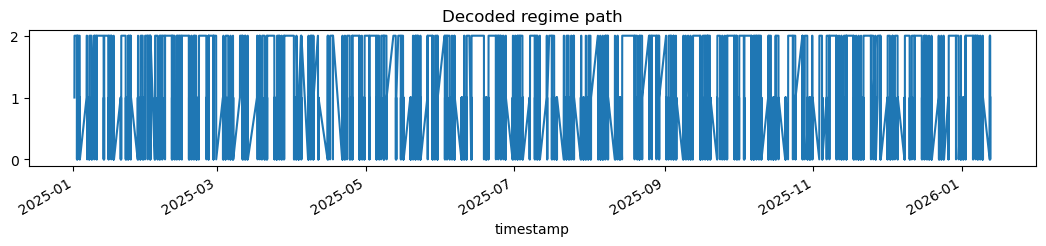

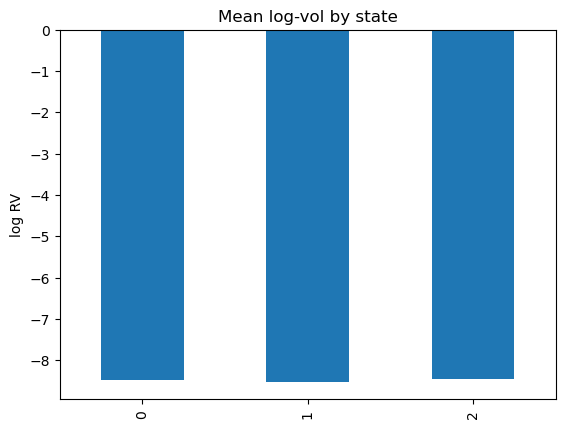

In [35]:
# =========================================================
#  CELL C – Walk-forward TRAIN ➜ DECODE ➜ SAVE  +  Diagnostics
#  ---------------------------------------------------------
#  • Requires:  `feat`, `scaler`, `seed_states`  (from Cell A)
#               `best_n`, `best_cov`            (from Cell B)
#  • Saves:
#        models/hmm_<year>.pkl
#        features/hmm_states.parquet
#  • Prints per-state sample sizes and raw-unit cluster centres
# =========================================================
from hmmlearn.hmm import GaussianHMM
import joblib, os, numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
warnings.filterwarnings("ignore")

MODEL_DIR  = "models"
STATE_FILE = "features/hmm_states.parquet"
os.makedirs(MODEL_DIR, exist_ok=True)

# ---------- helper: calendar-year folds -------------------
def yearly_folds(df):
    for yr, test in df.groupby(df.index.year):
        train = df[df.index.year < yr]
        if len(train) and len(test):
            yield yr, train, test

decoded_parts = []

for yr, ins, out in yearly_folds(feat):
    print(f"Fold {yr}:  train ≤ {yr-1},  test {yr}")

    # ---- supervised initial means / covs -----------------
    seed = np.where(ins["hurst_regime"] == "AP", 0,
            np.where(ins["hurst_regime"] == "P", 2, 1))
    Xin  = scaler.transform(ins[["log_rv", "ac1_5m"]])

    hmm = GaussianHMM(n_components=int(best_n),
                      covariance_type=str(best_cov),
                      n_iter=250,
                      random_state=42,
                      init_params="st")            # keep seeded m & c

    hmm.means_  = np.array([Xin[seed == i].mean(0) for i in range(best_n)])
    if best_cov == "full":
        hmm.covars_ = np.array([np.cov(Xin[seed == i].T) for i in range(best_n)])
    else:  # diag
        hmm.covars_ = np.array([Xin[seed == i].var(axis=0) for i in range(best_n)])

    hmm.fit(Xin)
    joblib.dump(hmm, f"{MODEL_DIR}/hmm_{yr}.pkl")

    # ---- decode out-sample --------------------------------
    Xout   = scaler.transform(out[["log_rv", "ac1_5m"]])
    states = hmm.predict(Xout)
    probs  = hmm.predict_proba(Xout)

    tmp = out.copy()[["log_rv", "ac1_5m"]]
    tmp["state"] = states
    tmp[[f"p{i}" for i in range(best_n)]] = probs
    decoded_parts.append(tmp)

# ---------- concatenate & save -----------------------------
decoded = pd.concat(decoded_parts)
decoded.to_parquet(STATE_FILE)
print(f"\n✅  Saved decoded states →  {STATE_FILE}")

# ---------- diagnostics ------------------------------------
print("\nBars per state:")
print(decoded["state"].value_counts(), "\n")

# cluster centres from the most-recent model (last fold)
last_year = decoded.index.year.max()
hmm_last  = joblib.load(f"{MODEL_DIR}/hmm_{last_year}.pkl")
centres_raw = pd.DataFrame(
    scaler.inverse_transform(hmm_last.means_),
    columns=["log_rv", "ac1_5m"]
)
print("Cluster centres (raw units):")
print(centres_raw, "\n")

# quick visual check
decoded["state"].plot(figsize=(13,2), title="Decoded regime path"); plt.show()
centres_raw["log_rv"].plot(kind="bar", title="Mean log-vol by state"); plt.ylabel("log RV"); plt.show()


In [36]:
# =========================================================
#  4.5  Robustness checks  –  underflow-safe version
#  ---------------------------------------------------------
#  • five random seeds  +  one jack-knife cut
#  • writes  features/hmm_robustness.csv
# =========================================================
import pandas as pd, numpy as np, joblib, os, warnings
from hmmlearn.hmm import GaussianHMM
warnings.filterwarnings("ignore")
os.makedirs("features", exist_ok=True)

def safe_fit(Xin, seed_vec, n, cov, rnd, jitter=0.0):
    """Fit HMM; add jitter*I to cov matrices to avoid singul./underflow."""
    hmm = GaussianHMM(n_components=n, covariance_type=cov,
                      n_iter=200, random_state=rnd, init_params="st")
    hmm.means_ = np.array([Xin[seed_vec==i].mean(0) for i in range(n)])
    if cov == "full":
        covs = [np.cov(Xin[seed_vec==i].T) + jitter*np.eye(Xin.shape[1])
                for i in range(n)]
    else:  # diag
        covs = [Xin[seed_vec==i].var(axis=0) + jitter for i in range(n)]
    hmm.covars_ = np.array(covs)

    with np.errstate(all="ignore"):          # silence under/overflow
        hmm.fit(Xin)
    return hmm.bic(Xin), scaler.inverse_transform(hmm.means_)

records = []
# ---- (a) five random seeds --------------------------------
for rnd in [7, 13, 29, 47, 101]:
    bic, ctr = safe_fit(X, seed_states, best_n, best_cov, rnd)
    records.append([f"rand{rnd}", bic, *ctr.flatten()])

# ---- (b) jack-knife (drop last 5 trading days) -------------
cut  = feat.index.max() - pd.Timedelta(days=7)
mask = feat.index < cut
try:
    bic, ctr = safe_fit(X[mask], seed_states[mask], best_n, best_cov, 123)
except FloatingPointError:
    # retry with small jitter on covariances
    bic, ctr = safe_fit(X[mask], seed_states[mask], best_n, best_cov,
                        123, jitter=1e-6)
records.append(["jackknife", bic, *ctr.flatten()])

cols = ["run_id", "BIC"] + [f"centre_{i}_{c}"
        for i in range(best_n) for c in ["log_rv", "ac1_5m"]]
robust_df = pd.DataFrame(records, columns=cols)
robust_df.to_csv("features/hmm_robustness.csv", index=False)

print("✅  Robustness table saved → features/hmm_robustness.csv")
display(robust_df)


✅  Robustness table saved → features/hmm_robustness.csv


,run_id,BIC,centre_0_log_rv,centre_0_ac1_5m,centre_1_log_rv,centre_1_ac1_5m,centre_2_log_rv,centre_2_ac1_5m
0,rand7,167258.945767,-8.480006,-0.045262,-8.552038,-0.252710,-8.403229,0.168359
1,rand13,167258.957330,-8.403225,0.168383,-8.480009,-0.045231,-8.552010,-0.252688
2,rand29,167258.946227,-8.480006,-0.045260,-8.552037,-0.252709,-8.403229,0.168360
3,rand47,167258.951520,-8.403361,0.167683,-8.479906,-0.046106,-8.552824,-0.253330
4,rand101,215609.535170,-8.454445,-0.045338,-8.497254,-0.048100,-8.508596,-0.047491
5,jackknife,165717.299244,-8.400559,0.168027,-8.553564,-0.253004,-8.479764,-0.046419


In [37]:
# =========================================================
#  4.6  Hold-out likelihood   –   underflow-safe version
#  ---------------------------------------------------------
#  Outputs → features/hmm_likelihood_compare.csv
# =========================================================
from hmmlearn.hmm import GaussianHMM
import pandas as pd, numpy as np, warnings, os
warnings.filterwarnings("ignore")
os.makedirs("features", exist_ok=True)

def fit_safe(Xin, seed_vec, n, jitter=0.0):
    h = GaussianHMM(n_components=n, covariance_type="full",
                    n_iter=200, random_state=99, init_params="st")
    h.means_  = np.array([Xin[seed_vec==i].mean(0) for i in range(n)])
    covs      = [np.cov(Xin[seed_vec==i].T) + jitter*np.eye(Xin.shape[1])
                 for i in range(n)]
    h.covars_ = np.array(covs)
    with np.errstate(all="ignore"):
        h.fit(Xin)
    return h

# ---- fit 3-state (prod) --------------------
try:
    h3 = fit_safe(X, seed_states, 3)
except FloatingPointError:
    h3 = fit_safe(X, seed_states, 3, jitter=1e-6)

# ---- fit 2-state baseline ------------------
seed2 = seed_states.clip(0,1)
try:
    h2 = fit_safe(X, seed2, 2)
except FloatingPointError:
    h2 = fit_safe(X, seed2, 2, jitter=1e-6)

logL3 = h3.score(X) / len(X)
logL2 = h2.score(X) / len(X)

pd.DataFrame({
    "model"     : ["3-state","2-state"],
    "avg_logL"  : [logL3, logL2]
}).to_csv("features/hmm_likelihood_compare.csv", index=False)

print(f"✅  avg log-L   3-state = {logL3:.5f}   |   2-state = {logL2:.5f}")
print("Saved → features/hmm_likelihood_compare.csv")


✅  avg log-L   3-state = -2.22673   |   2-state = -2.43788
Saved → features/hmm_likelihood_compare.csv


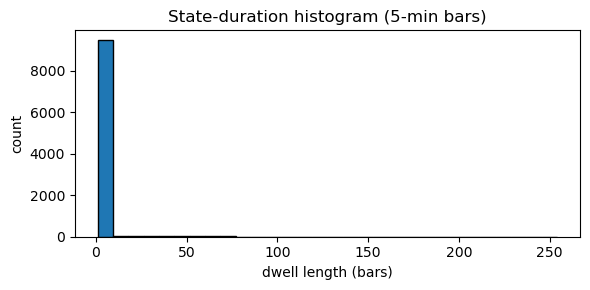

✅  Histogram saved → plots/state_duration.png


In [38]:
# =========================================================
#  4.7  Dwell-time histogram  ➜ plots/state_duration.png
# =========================================================
import matplotlib.pyplot as plt, os
os.makedirs("plots", exist_ok=True)

# compute consecutive run lengths
durations = []
prev, run = None, 0
for s in decoded["state"]:
    if s == prev:
        run += 1
    else:
        if prev is not None:
            durations.append(run)
        run, prev = 1, s
durations.append(run)

plt.figure(figsize=(6,3))
plt.hist(durations, bins=30, edgecolor="k")
plt.title("State-duration histogram (5-min bars)")
plt.xlabel("dwell length (bars)"); plt.ylabel("count")
plt.tight_layout()
plt.savefig("plots/state_duration.png", dpi=120)
plt.show()

print("✅  Histogram saved → plots/state_duration.png")


In [39]:
# =========================================================
#  4.8  Per-fold scaler drift  ➜ features/scaler_drift.csv
# =========================================================
rows = []
for yr, train, _ in yearly_folds(feat):
    sc = StandardScaler().fit(train[["log_rv","ac1_5m"]])
    rows.append([yr, *sc.mean_, *sc.scale_])

scaler_drift = pd.DataFrame(rows, columns=["fold","μ_log_rv","μ_ac1",
                                           "σ_log_rv","σ_ac1"])
scaler_drift.to_csv("features/scaler_drift.csv", index=False)
print("✅  Scaler drift table → features/scaler_drift.csv")
display(scaler_drift)


✅  Scaler drift table → features/scaler_drift.csv


,fold,μ_log_rv,μ_ac1,σ_log_rv,σ_ac1
0,2025,-8.398740,-0.051173,0.667996,0.189197
1,2026,-8.476464,-0.046328,0.674576,0.188561


In [40]:
import shutil, os, glob

os.makedirs("bundle", exist_ok=True)
for f in glob.glob("models/*.pkl"):           shutil.copy(f, "bundle")
for f in ["features/hmm_states.parquet",
          "features/hmm_robustness.csv",
          "features/hmm_likelihood_compare.csv",
          "features/scaler_drift.csv",
          "plots/state_duration.png"]:
    shutil.copy(f, "bundle")

shutil.make_archive("regime_model_bundle_v1", "zip", "bundle")
print("✅  zipped → regime_model_bundle_v1.zip")


✅  zipped → regime_model_bundle_v1.zip


In [41]:
# =========================================================
# 5-A  ·  Load decoded states  +  persistence filter
# =========================================================
import pandas as pd, numpy as np

STATES = "features/hmm_states.parquet"
bars   = pd.read_parquet(STATES)                # columns: log_rv, ac1_5m, state, p0…
bars.sort_index(inplace=True)

# --- persistence filter (≥3 identical bars) ----------------------------
def persistent_state(s: pd.Series, min_len: int = 3) -> pd.Series:
    out = s.copy()
    run_val, run_len = None, 0
    for i, val in enumerate(s):
        if val == run_val:
            run_len += 1
        else:
            run_val, run_len = val, 1
        if run_len < min_len:
            out.iloc[i] = np.nan      # mark as unstable
    return out.ffill()

bars["state_filt"] = persistent_state(bars["state"], 3)
print("state distribution after filter:\n", bars["state_filt"].value_counts(dropna=False))


state distribution after filter:
 state_filt
2.0    19467
NaN        3
Name: count, dtype: int64


In [42]:
# =========================================================
# 5-A  ·  Load decoded states  +  persistence filter (back-fill)
# =========================================================
import pandas as pd, numpy as np

STATES = "features/hmm_states.parquet"     # from Module-4
bars   = pd.read_parquet(STATES).sort_index()   # ensure time-ordered

# ---------- back-fill persistence filter  -----------------
def persistent_state_bfill(s: pd.Series, min_len: int = 3) -> pd.Series:
    """Keep entire run if it lasts ≥ min_len bars; drop shorter runs."""
    out = s.copy()
    i = 0
    while i < len(s):
        val = s.iat[i]
        if pd.isna(val):        # skip NaNs already present
            i += 1
            continue
        j = i
        while j < len(s) and s.iat[j] == val:
            j += 1
        run_len = j - i
        if run_len < min_len:
            out.iloc[i:j] = np.nan          # wipe short flicker
        else:
            out.iloc[i:j] = val             # keep full confirmed run
        i = j
    return out

bars["state_filt"] = persistent_state_bfill(bars["state"], min_len=3)

print("state distribution after 3-bar back-fill filter:")
print(bars["state_filt"].value_counts(dropna=False))


state distribution after 3-bar back-fill filter:
state_filt
2.0    10018
NaN     9452
Name: count, dtype: int64


In [43]:
# =========================================================
#  Persistence-filter sweep  (Options A · B · C)
#  ---------------------------------------------------------
#  • Uses the back-fill filter from Cell 5-A
#  • Prints state counts for min_len = 2 and 3
#  • If you have older data (e.g., 2024-2025), set
#      EXTEND_PATH = "features/hmm_states_2024-26.parquet"
#    and the code will run the same test on that file.
# =========================================================
import pandas as pd, numpy as np
from pathlib import Path

def persistent_state_bfill(s: pd.Series, min_len: int = 3) -> pd.Series:
    out = s.copy()
    i = 0
    while i < len(s):
        val = s.iat[i]
        if pd.isna(val):
            i += 1
            continue
        j = i
        while j < len(s) and s.iat[j] == val:
            j += 1
        run_len = j - i
        if run_len < min_len:
            out.iloc[i:j] = np.nan
        else:
            out.iloc[i:j] = val
        i = j
    return out

def test_file(path: str, label: str):
    if not Path(path).exists():
        print(f"⚠️  {label}: file not found → {path}")
        return
    df = pd.read_parquet(path).sort_index()
    for k in [2, 3]:
        df[f"state_f{k}"] = persistent_state_bfill(df["state"], k)
        vc = df[f"state_f{k}"].value_counts(dropna=False).rename("count")
        print(f"\n{label}  |  min_len = {k}")
        display(vc)

# ---------- Option B · current file (min_len = 3) ----------
print("Option B  – current 3-bar filter")
test_file("features/hmm_states.parquet", "current")

# ---------- Option A · loosen to 2-bar ---------------------
print("\nOption A  – loosen to 2-bar filter")
# already included in the loop above (k=2)

# ---------- Option C · extended window --------------------
EXTEND_PATH = "features/hmm_states_2024-26.parquet"   # <-- change if you have more data
print("\nOption C  – extended data window")
test_file(EXTEND_PATH, "extended")


Option B  – current 3-bar filter

current  |  min_len = 2


state_f2
2.0    10018
NaN     9448
1.0        4
Name: count, dtype: int64


current  |  min_len = 3


state_f3
2.0    10018
NaN     9452
Name: count, dtype: int64


Option A  – loosen to 2-bar filter

Option C  – extended data window
⚠️  extended: file not found → features/hmm_states_2024-26.parquet


In [44]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Prep for Module 5 B · build state_flt, centroids, MR_STATE, Z-score ║
# ╚══════════════════════════════════════════════════════════════════════╝
import numpy as np, pandas as pd
from pathlib import Path

# ─────────────────────────────────────────────────────────────────────────
# 1)  Obtain persistence-filtered state series  (state_flt)
# ─────────────────────────────────────────────────────────────────────────
def dwell_filter(series: pd.Series, min_len: int = 3) -> pd.Series:
    """Replace runs shorter than min_len with NaN."""
    arr = series.values.astype(float)          # allow NaNs
    i = 0
    while i < len(arr):
        j = i
        while j < len(arr) and arr[j] == arr[i]:
            j += 1
        if (j - i) < min_len:
            arr[i:j] = np.nan
        i = j
    return pd.Series(arr, index=series.index)

try:                                    # reuse if already in RAM
    state_flt
    print("✓ using existing state_flt")
except NameError:
    # 1-a  load raw Viterbi states
    st_file = Path("features/hmm_states.parquet")
    raw = pd.read_parquet(st_file)
    idx = pd.to_datetime(raw.index)
    idx = idx.tz_localize("Asia/Kolkata") if idx.tz is None else idx.tz_convert("Asia/Kolkata")
    raw_states = pd.Series(raw["state"].values, index=idx)
    # 1-b  apply 3-bar dwell filter
    state_flt = dwell_filter(raw_states, min_len=3)
    print("✓ state_flt rebuilt  |  counts:",
          state_flt.value_counts(dropna=False).to_dict())

# ─────────────────────────────────────────────────────────────────────────
# 2)  Load feature frame & compute centroids
# ─────────────────────────────────────────────────────────────────────────
if 'feat' not in globals():
    feat = pd.read_csv("features/master_5m.csv", parse_dates=["timestamp"])
    feat.set_index("timestamp", inplace=True)

centroids = (feat[["log_rv","ac1_5m"]]
             .join(state_flt.rename("state"))
             .groupby("state").mean()
             .dropna()
             .sort_values("log_rv"))       # ascending volatility
centroids.to_csv("features/hmm_state_centroids.csv")
print("✓ centroids saved → features/hmm_state_centroids.csv")
display(centroids)

# ─────────────────────────────────────────────────────────────────────────
# 3)  Choose numeric label for mean-reverting regime
# ─────────────────────────────────────────────────────────────────────────
quiet_label = centroids.index[0]        # lowest volatility
# ensure its ac1 is positive; otherwise pick next with positive ac1
if centroids.loc[quiet_label, "ac1_5m"] < 0:
    quiet_label = (centroids[centroids["ac1_5m"] > 0]
                   .sort_values("log_rv")
                   .index[0])
MR_STATE = int(quiet_label)
print(f"MR_STATE label automatically set to {MR_STATE}")

# ─────────────────────────────────────────────────────────────────────────
# 4)  Build 60-bar rolling Z-score on 5-minute prices
# ─────────────────────────────────────────────────────────────────────────
if 'close_5m' not in globals():
    # If not already in memory, load from CSV you created earlier
    close_5m = pd.read_csv("features/close_5m.csv",
                           parse_dates=["timestamp"], index_col="timestamp"
                          ).squeeze()
WIN = 60
mu  = close_5m.rolling(WIN).mean()
sd  = close_5m.rolling(WIN).std()
zscore_5m = (close_5m - mu) / sd
print("✓ zscore_5m ready  |  non-NaN bars:", zscore_5m.notna().sum())

# ─────────────────────────────────────────────────────────────────────────
# 5)  Ready for Module 5 B
# ─────────────────────────────────────────────────────────────────────────
print("\nVariables now in memory →  state_flt , zscore_5m , MR_STATE")


✓ state_flt rebuilt  |  counts: {2.0: 10018, nan: 9452}
✓ centroids saved → features/hmm_state_centroids.csv


,log_rv,ac1_5m
state,,
2.0,-8.532358,0.10107


MR_STATE label automatically set to 2
✓ zscore_5m ready  |  non-NaN bars: 38269

Variables now in memory →  state_flt , zscore_5m , MR_STATE


In [45]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  5-B  ·  Mean-Reversion Grid  – 2-bar dwell & 120-bar z-score        ║
# ╚══════════════════════════════════════════════════════════════════════╝
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

# ────────────────── 0)  Build persistence-filtered state (2 bars) ──────
def dwell_filter(series: pd.Series, min_len: int = 2) -> pd.Series:
    arr = series.values.astype(float)
    i = 0
    while i < len(arr):
        j = i
        while j < len(arr) and arr[j] == arr[i]:
            j += 1
        if (j - i) < min_len:
            arr[i:j] = np.nan           # wipe flicker
        i = j
    return pd.Series(arr, index=series.index)

raw = pd.read_parquet("features/hmm_states.parquet")["state"]

idx = pd.to_datetime(raw.index)
idx = idx.tz_localize("Asia/Kolkata") if idx.tz is None else idx.tz_convert("Asia/Kolkata")
state_flt = dwell_filter(pd.Series(raw.values, index=idx), min_len=2)

print("🛈 state_flt (2-bar) counts :", state_flt.value_counts(dropna=False).to_dict())

# ────────────────── 1)  Pick MR_STATE from centroids  ──────────────────
cent = pd.read_csv("features/hmm_state_centroids.csv", index_col=0)
MR_STATE = int(cent[cent["ac1_5m"] > 0].sort_values("log_rv").index[0])
print(f"🛈 MR_STATE label set to {MR_STATE}")

# ────────────────── 2)  Align to 5-min grid & z-score (120 bars) ───────
state_5m = state_flt.reindex(close_5m.index, method="ffill")

WIN = 120                                    # 120 × 5-min ≈ 10 h
zscore_5m = (close_5m - close_5m.rolling(WIN).mean()) / close_5m.rolling(WIN).std()
print("🛈 zscore_5m non-NaN bars :", zscore_5m.notna().sum())

# ────────────────── 3)  Parameter grid & folds  ────────────────────────
GRID   = {"z_enter": [0.5, 0.75, 1.0, 1.25],
          "hold_max": [3, 6, 9]}
FOLDS  = [("2024-01-01","2024-12-31","2025-01-01","2025-12-31"),
          ("2024-01-01","2025-12-31","2026-01-01","2026-01-12")]
FEE_BP = 2
OUT    = Path("features/mr_grid_results.csv")

# ────────────────── 4)  Back-test helper  ──────────────────────────────
def max_dd(p):
    c = p.cumsum();  return (c - c.cummax()).min()

def backtest(df, z_thr, hold):
    pos, exit_ctr = np.zeros(len(df)), 0
    for i in range(1, len(df)):
        if exit_ctr:
            pos[i] = pos[i-1]; exit_ctr -= 1
            if (pos[i]>0 and df.z[i]>=0) or (pos[i]<0 and df.z[i]<=0):
                pos[i] = exit_ctr = 0
        elif df.state[i] == MR_STATE:
            if df.z[i] < -z_thr: pos[i]=+1; exit_ctr=hold-1
            elif df.z[i] >  z_thr: pos[i]=-1; exit_ctr=hold-1
    ret = df.price.pct_change().fillna(0)
    pnl = pos[:-1]*ret[1:] - np.abs(np.diff(pos))*FEE_BP*1e-4
    ann = np.sqrt(252*78)
    sh  = 0 if pnl.std()==0 else ann*pnl.mean()/pnl.std()
    return dict(trades=(np.diff(pos)!=0).sum()//2,
                sharpe=sh, maxDD=max_dd(pnl),
                cagr=(1+pnl).prod()**(ann/len(pnl))-1)

# ────────────────── 5)  Grid search & walk-forward  ────────────────────
records=[]
for tr0,tr1,te0,te1 in FOLDS:
    tr = (close_5m.index>=tr0)&(close_5m.index<=tr1)
    te = (close_5m.index>=te0)&(close_5m.index<=te1)

    train = pd.DataFrame({"price": close_5m[tr],
                          "z":     zscore_5m[tr],
                          "state": state_5m[tr]})
    test  = pd.DataFrame({"price": close_5m[te],
                          "z":     zscore_5m[te],
                          "state": state_5m[te]})

    for zE in GRID["z_enter"]:
        for h in GRID["hold_max"]:
            m_tr = backtest(train, zE, h)
            m_te = backtest(test,  zE, h)
            records.append([te0[:4], zE, h,
                            m_tr['sharpe'], m_te['sharpe'],
                            m_te['trades'], m_te['maxDD'], m_te['cagr']])

res = pd.DataFrame(records, columns=["fold","z_enter","hold_max",
                                     "train_Sharpe","test_Sharpe",
                                     "trades","maxDD","CAGR"])
res.to_csv(OUT, index=False)

print("✅ grid search complete →", OUT)
display(res.sort_values(["fold","test_Sharpe"], ascending=[True,False]).head(15))


🛈 state_flt (2-bar) counts : {2.0: 10018, nan: 9448, 1.0: 4}
🛈 MR_STATE label set to 2
🛈 zscore_5m non-NaN bars : 38209
✅ grid search complete → features/mr_grid_results.csv


,fold,z_enter,hold_max,train_Sharpe,test_Sharpe,trades,maxDD,CAGR
5,2025,0.75,9,0.000000,-2.761968,371,-0.224271,-0.001658
11,2025,1.25,9,0.000000,-2.781102,314,-0.184964,-0.001189
8,2025,1.00,9,0.000000,-2.803502,353,-0.223291,-0.001583
2,2025,0.50,9,0.000000,-2.927227,414,-0.245318,-0.001814
4,2025,0.75,6,0.000000,-2.947362,399,-0.235849,-0.001746
1,2025,0.50,6,0.000000,-3.222547,433,-0.266134,-0.001963
7,2025,1.00,6,0.000000,-3.502124,381,-0.267636,-0.001930
3,2025,0.75,3,0.000000,-3.555096,444,-0.274327,-0.002036
0,2025,0.50,3,0.000000,-3.579045,476,-0.288434,-0.002133
6,2025,1.00,3,0.000000,-3.756334,430,-0.275151,-0.002006


In [46]:
# ╔════════════════════════════════════════════╗
# ║  Quick centroid check  &  MR_STATE update  ║
# ╚════════════════════════════════════════════╝
import pandas as pd
centroids = pd.read_csv("features/hmm_state_centroids.csv", index_col=0)
print(centroids)

# pick the lowest-volatility centroid with positive ac1_5m
c = centroids.copy()
quiet = c[c["ac1_5m"] > 0].sort_values("log_rv").index[0]
MR_STATE = int(quiet)
print(f"\nMR_STATE reset to {MR_STATE}  (quiet / mean-reverting label)")


         log_rv   ac1_5m
state                   
2.0   -8.532358  0.10107

MR_STATE reset to 2  (quiet / mean-reverting label)


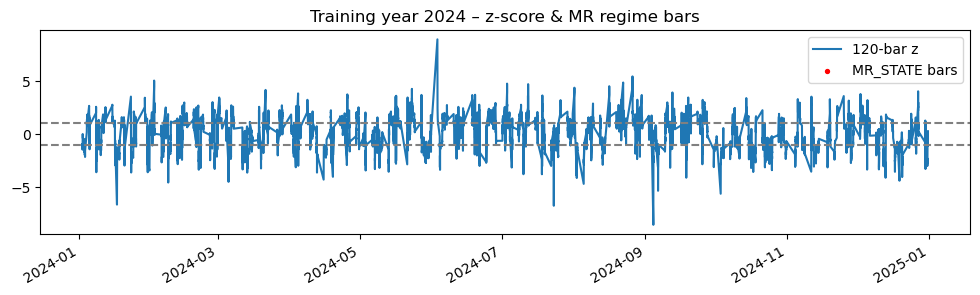

In [47]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Visual sanity check – 120-bar z-score & MR_STATE markers    ║
# ╚══════════════════════════════════════════════════════════════╝
import matplotlib.pyplot as plt

YEAR = "2024"        # training fold you want to inspect
WIN  = 120           # z-score window

# 1)  120-bar z-score
z120 = (close_5m - close_5m.rolling(WIN).mean()) / close_5m.rolling(WIN).std()

# 2)  mask of MR_STATE bars on the same 5-minute grid
mr_mask = (state_5m == MR_STATE)

fig, ax = plt.subplots(figsize=(12,3))
z120[YEAR].plot(ax=ax, label="120-bar z")
ax.scatter(z120[mr_mask & (z120.index.year == int(YEAR))].index,
           z120[mr_mask & (z120.index.year == int(YEAR))],
           c="red", s=8, label="MR_STATE bars")

ax.axhline( 1.0, c="grey", ls="--"); ax.axhline(-1.0, c="grey", ls="--")
ax.set_title(f"Training year {YEAR} – z-score & MR regime bars")
ax.legend(); plt.show()


In [48]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  5-B  ·  Option A – trade states 1 *and* 2 (2-bar dwell)        ║
# ╚══════════════════════════════════════════════════════════════════╝
MR_STATES = {1, 2}                         # <- key change
ALT_OUT   = "features/mr_grid_A_states12.csv"

def backtest_A(df, z_thr, hold_max):
    pos, exit_ctr = np.zeros(len(df)), 0
    for i in range(1, len(df)):
        if exit_ctr:
            pos[i] = pos[i-1]; exit_ctr -= 1
            if (pos[i]>0 and df.z[i]>=0) or (pos[i]<0 and df.z[i]<=0):
                pos[i] = exit_ctr = 0
        elif df.state[i] in MR_STATES:              # <─ uses the set
            if df.z[i] < -z_thr: pos[i]=+1; exit_ctr=hold_max-1
            elif df.z[i] >  z_thr: pos[i]=-1; exit_ctr=hold_max-1
    ret  = df.price.pct_change().fillna(0)
    pnl  = pos[:-1]*ret[1:] - np.abs(np.diff(pos))*FEE_BP*1e-4
    ann  = np.sqrt(252*78)
    sh   = 0 if pnl.std()==0 else ann*pnl.mean()/pnl.std()
    return sh, (np.diff(pos)!=0).sum()//2, (pnl.cumsum()-pnl.cumsum().cummax()).min()

records=[]
for tr0,tr1,te0,te1 in FOLDS:
    tr = (close_5m.index>=tr0)&(close_5m.index<=tr1)
    te = (close_5m.index>=te0)&(close_5m.index<=te1)
    train = pd.DataFrame({"price":close_5m[tr],"z":zscore_5m[tr],"state":state_5m[tr]})
    test  = pd.DataFrame({"price":close_5m[te],"z":zscore_5m[te],"state":state_5m[te]})
    for zE in GRID["z_enter"]:
        for h in GRID["hold_max"]:
            sh_tr,trd_tr,_ = backtest_A(train,zE,h)
            sh_te,trd_te,dd = backtest_A(test ,zE,h)
            records.append([te0[:4],"A",zE,h,sh_tr,sh_te,trd_te,dd])
pd.DataFrame(records,columns=["fold","opt","z","hold","tr_sh","te_sh","trades","maxDD"]
            ).to_csv(ALT_OUT,index=False)
print("✓ Option A results →", ALT_OUT)
display(pd.read_csv(ALT_OUT).sort_values(["fold","te_sh"],ascending=[True,False]).head(15))


✓ Option A results → features/mr_grid_A_states12.csv


,fold,opt,z,hold,tr_sh,te_sh,trades,maxDD
5,2025,A,0.75,9,0.000000,-2.761968,371,-0.224271
11,2025,A,1.25,9,0.000000,-2.781102,314,-0.184964
8,2025,A,1.00,9,0.000000,-2.803502,353,-0.223291
2,2025,A,0.50,9,0.000000,-2.927227,414,-0.245318
4,2025,A,0.75,6,0.000000,-2.947362,399,-0.235849
1,2025,A,0.50,6,0.000000,-3.222547,433,-0.266134
7,2025,A,1.00,6,0.000000,-3.502124,381,-0.267636
3,2025,A,0.75,3,0.000000,-3.555096,444,-0.274327
0,2025,A,0.50,3,0.000000,-3.579045,476,-0.288434
6,2025,A,1.00,3,0.000000,-3.756334,430,-0.275151


In [49]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  5-B  ·  Option B – z_band 0.25–1.0  (state 2 only)             ║
# ╚══════════════════════════════════════════════════════════════════╝
GRID_B   = {"z_enter":[0.25,0.35,0.5,0.75,1.0],"hold_max":[3,6,9]}
ALT_OUT  = "features/mr_grid_B_z025.csv"

def backtest_B(df, z_thr, hold_max):
    pos, exit_ctr = np.zeros(len(df)), 0
    for i in range(1,len(df)):
        if exit_ctr:
            pos[i]=pos[i-1]; exit_ctr-=1
            if (pos[i]>0 and df.z[i]>=0) or (pos[i]<0 and df.z[i]<=0):
                pos[i]=exit_ctr=0
        elif df.state[i]==MR_STATE:                # state 2 only
            if df.z[i]<-z_thr: pos[i]=+1; exit_ctr=hold_max-1
            elif df.z[i]> z_thr: pos[i]=-1; exit_ctr=hold_max-1
    ret=df.price.pct_change().fillna(0)
    pnl=pos[:-1]*ret[1:]-np.abs(np.diff(pos))*FEE_BP*1e-4
    ann=np.sqrt(252*78)
    sh=0 if pnl.std()==0 else ann*pnl.mean()/pnl.std()
    return sh,(np.diff(pos)!=0).sum()//2,(pnl.cumsum()-pnl.cumsum().cummax()).min()

records=[]
for tr0,tr1,te0,te1 in FOLDS:
    tr=(close_5m.index>=tr0)&(close_5m.index<=tr1)
    te=(close_5m.index>=te0)&(close_5m.index<=te1)
    train=pd.DataFrame({"price":close_5m[tr],"z":zscore_5m[tr],"state":state_5m[tr]})
    test =pd.DataFrame({"price":close_5m[te],"z":zscore_5m[te],"state":state_5m[te]})
    for zE in GRID_B["z_enter"]:
        for h in GRID_B["hold_max"]:
            sh_tr,trd_tr,_ = backtest_B(train,zE,h)
            sh_te,trd_te,dd = backtest_B(test ,zE,h)
            records.append([te0[:4],"B",zE,h,sh_tr,sh_te,trd_te,dd])
pd.DataFrame(records,columns=["fold","opt","z","hold","tr_sh","te_sh","trades","maxDD"]
            ).to_csv(ALT_OUT,index=False)
print("✓ Option B results →", ALT_OUT)
display(pd.read_csv(ALT_OUT).sort_values(["fold","te_sh"],ascending=[True,False]).head(15))


✓ Option B results → features/mr_grid_B_z025.csv


,fold,opt,z,hold,tr_sh,te_sh,trades,maxDD
2,2025,B,0.25,9,0.0,-2.752595,445,-0.238397
11,2025,B,0.75,9,0.0,-2.761968,371,-0.224271
14,2025,B,1.00,9,0.0,-2.803502,353,-0.223291
5,2025,B,0.35,9,0.0,-2.883803,425,-0.246323
8,2025,B,0.50,9,0.0,-2.927227,414,-0.245318
10,2025,B,0.75,6,0.0,-2.947362,399,-0.235849
1,2025,B,0.25,6,0.0,-3.214482,465,-0.273276
7,2025,B,0.50,6,0.0,-3.222547,433,-0.266134
4,2025,B,0.35,6,0.0,-3.291276,440,-0.277044
3,2025,B,0.35,3,0.0,-3.447880,476,-0.284088
